## Plotting and Metrics

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import plot_utils as pu

import sys
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key, build_row_normalized_adjacency
from models.analysis_utils import (
    evaluate_validation_model,
    align_rollout_pair,
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    plot_box_per_timestep,
    plot_violin_per_timestep,
    compute_mean_prediction_error,
    compute_max_prediction_error,
)
from models.adjacency_based.degroot import (
    fit_degroot_adjacency_scalar,
    degroot_rollout_prediction,
)
from models.adjacency_based.friedkin_johnsen import (
    fit_base_friedkin_johnson_adjency,
    base_friedkin_johnsen_adjacency_rollout,
    select_base_friedkin_johnsen_adjacency_lambda,
    fit_friedkin_johnsen_adjacency,
    select_friedkin_johnsen_adjacency_lambdas,
    friedkin_johnsen_adjacency_rollout,
)
from models.adjacency_based.homophily import (
    fit_homophily,
    rollout_with_homophily,
    fit_homophily_stubborness,
    rollout_with_homophily_stubborness,
    fit_homophily_friedkin_johnsen,
    rollout_with_homophily_friedkin_johnsen,
)

from models.fixed_graph.degroot import fit_row_stochastic_W_from_pooled_runs, degroot_rollout_prediction as fixed_graph_degroot_rollout_prediction
from models.fixed_graph.friedkin_johnsen import (
    select_friedkin_johnsen_lambdas,
    fit_friedkin_johnsen,
    friedkin_johnsen_rollout_prediction,
)
from models.fixed_graph.homophily import (
    fit_fg_homophily,
    rollout_fg_homophily,
    fit_fg_fj_homophily,
    rollout_fg_fj_homophily,
    fit_fg_fj_bias_homophily,
    rollout_fg_fj_bias_homophily,
)


### Fixed Graph vs Adjacency Based

### Componenets of Adjacency Based

In [4]:
# Set the LLM and topic
ROOT = Path('.').resolve()
LLM_NAME = 'llama3.1'
TOPIC_NAME = 'vaccines'
SPLIT_NAME = 'train'
RUNS_ROOT = ROOT / 'runs' / LLM_NAME / TOPIC_NAME / SPLIT_NAME
train_path = RUNS_ROOT

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 250,
    'rollout_horizon_cap': 20,
    'sample_plot_horizon': 15,
}

print('Project root:', ROOT)
print('Runs root:', RUNS_ROOT)
print('Configured LLM/topic/split:', LLM_NAME, TOPIC_NAME, SPLIT_NAME)

RUN_DIRS = sorted([p for p in RUNS_ROOT.iterdir() if p.is_dir()])
print('Runs found:', len(RUN_DIRS))
for run_dir in RUN_DIRS[:20]:
    print(' ', run_dir.name)

RUN_DATA = {run_dir.name: load_run_data(run_dir) for run_dir in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({agent for data in RUN_DATA.values() for agent in data['agent_ids']}, key=_numeric_agent_key)
N_AGENTS = len(GLOBAL_AGENT_IDS)
GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    run_name: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for run_name, data in RUN_DATA.items()
}
RUN_TRAJ = {run_name: traj_mask[0] for run_name, traj_mask in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {run_name: traj_mask[1] for run_name, traj_mask in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {run_name: build_neighbors_index(data, GLOBAL_AGENT_IDS) for run_name, data in RUN_DATA.items()}

print('Global agent count:', N_AGENTS)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for run_name in sorted(RUN_TRAJ.keys()):
    traj = np.asarray(RUN_TRAJ[run_name], dtype=float)
    print(f'{run_name}: trajectory shape={traj.shape}, horizon={traj.shape[0] - 1}')



Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Runs root: /Users/samuelli/Documents/code/llm/llm-network/modeling/runs/llama3.1/vaccines/train
Configured LLM/topic/split: llama3.1 vaccines train
Runs found: 24
  run_20260505-221153
  run_20260505-223218
  run_20260505-235914
  run_20260506-005352
  run_20260506-032438
  run_20260506-034454
  run_20260506-040513
  run_20260506-042531
  run_20260506-044548
  run_20260506-050608
  run_20260506-054640
  run_20260506-060658
  run_20260506-062723
  run_20260506-064741
  run_20260506-070759
  run_20260506-072817
  run_20260506-082918
  run_20260506-084948
  run_20260506-091006
  run_20260506-093022
Global agent count: 30
Global init priors available: 30
run_20260505-221153: trajectory shape=(14, 30), horizon=13
run_20260505-223218: trajectory shape=(14, 30), horizon=13
run_20260505-235914: trajectory shape=(14, 30), horizon=13
run_20260506-005352: trajectory shape=(14, 30), horizon=13
run_20260506-032438: trajectory sha

In [3]:
DEGROOT_ADJ = fit_degroot_adjacency_scalar(RUN_TRAJ, RUN_NEIGHBORS)
GLOBAL_W = DEGROOT_ADJ['W_blocks']
DEGROOT_GAMMA = DEGROOT_ADJ['gamma']
DEGROOT_POOL_MSE = DEGROOT_ADJ['mse_pool']

LAMBDA_GRID = np.linspace(0.0, 1.0, 50)

BEST_BASE_FJ_ADJ, BASE_FJ_ADJ_GRID = select_base_friedkin_johnsen_adjacency_lambda(RUN_TRAJ, RUN_NEIGHBORS, LAMBDA_GRID)
BASE_FJ_ADJ_L1 = BEST_BASE_FJ_ADJ['lambda1']
BASE_FJ_ADJ_FIT = fit_base_friedkin_johnson_adjency(RUN_TRAJ, RUN_NEIGHBORS, BASE_FJ_ADJ_L1)
BASE_FJ_ADJ_GAMMA = BASE_FJ_ADJ_FIT['gamma']
BASE_FJ_ADJ_W = BASE_FJ_ADJ_FIT['W_blocks']
BASE_FJ_ADJ_POOL_MSE = BASE_FJ_ADJ_FIT['mse_pool']

BEST_FJ_ADJ, FJ_ADJ_GRID = select_friedkin_johnsen_adjacency_lambdas(RUN_TRAJ, RUN_NEIGHBORS, LAMBDA_GRID)
FJ_ADJ_L1 = BEST_FJ_ADJ['lambda1']
FJ_ADJ_L2 = BEST_FJ_ADJ['lambda2']
FJ_ADJ_FIT = fit_friedkin_johnsen_adjacency(RUN_TRAJ, RUN_NEIGHBORS, FJ_ADJ_L1, FJ_ADJ_L2)
FJ_ADJ_GAMMA = FJ_ADJ_FIT['gamma']
FJ_ADJ_BIAS = FJ_ADJ_FIT['bias']
FJ_ADJ_W = FJ_ADJ_FIT['W_blocks']
FJ_ADJ_POOL_MSE = FJ_ADJ_FIT['mse_pool']

HOMOPHILY = fit_homophily(RUN_TRAJ, RUN_NEIGHBORS, gamma0=1.0)
HOMOPHILY_A = HOMOPHILY['Abar_blocks']
HOMOPHILY_GAMMA = HOMOPHILY['gamma']
HOMOPHILY_LAMBDA = HOMOPHILY['lambda']

BEST_HOMO_FJ = fit_homophily_friedkin_johnsen(RUN_TRAJ, RUN_NEIGHBORS, gamma0=HOMOPHILY_GAMMA)
HOMO_FJ_A = BEST_HOMO_FJ['Abar_blocks']
HOMO_FJ_GAMMA = BEST_HOMO_FJ['gamma']
HOMO_FJ_L1 = BEST_HOMO_FJ['lambda1']
HOMO_FJ_LSELF = BEST_HOMO_FJ['lambda_self']

BEST_HOMO_STUB = fit_homophily_stubborness(RUN_TRAJ, RUN_NEIGHBORS, gamma0=HOMOPHILY_GAMMA)
HOMO_STUB_A = BEST_HOMO_STUB['Abar_blocks']
HOMO_STUB_GAMMA = BEST_HOMO_STUB['gamma']
HOMO_STUB_BIAS = BEST_HOMO_STUB['bias']
HOMO_STUB_L1 = BEST_HOMO_STUB['lambda1']
HOMO_STUB_L2 = BEST_HOMO_STUB['lambda2']
HOMO_STUB_LSELF = BEST_HOMO_STUB['lambda_self']

print('Adjacency fit summary')
print('  DeGroot gamma:', DEGROOT_GAMMA)
print('  DeGroot pooled MSE:', DEGROOT_POOL_MSE)
print('  Base FJ (no bias) lambda1:', BASE_FJ_ADJ_L1)
print('  Base FJ (no bias) gamma:', BASE_FJ_ADJ_GAMMA)
print('  Base FJ (no bias) pooled MSE:', BASE_FJ_ADJ_POOL_MSE)
print('  FJ adjacency lambdas:', (FJ_ADJ_L1, FJ_ADJ_L2))
print('  FJ adjacency gamma:', FJ_ADJ_GAMMA)
print('  FJ adjacency bias:', FJ_ADJ_BIAS)
print('  FJ adjacency pooled MSE:', FJ_ADJ_POOL_MSE)
print('  Homophily lambda:', HOMOPHILY_LAMBDA)
print('  Homophily gamma:', HOMOPHILY_GAMMA)
print('  Homophily pooled MSE:', HOMOPHILY['mse_pool'])
print('  Homophily FJ pooled MSE:', BEST_HOMO_FJ['mse_pool'])
print('  Homophily stubbornness pooled MSE:', BEST_HOMO_STUB['mse_pool'])

# Load test split and build test trajectories/neighbors
TEST_RUNS_ROOT = ROOT / 'runs' / LLM_NAME / TOPIC_NAME / 'test'
TEST_RUN_DIRS = sorted([p for p in TEST_RUNS_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {run_dir.name: load_run_data(run_dir) for run_dir in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    run_name: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for run_name, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {run_name: traj_mask[0] for run_name, traj_mask in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {run_name: build_neighbors_index(data, GLOBAL_AGENT_IDS) for run_name, data in TEST_RUN_DATA.items()}

# Build test-time adjacency/weight maps using the fitted parameters from training
TEST_DEGROOT_W = {
    rn: DEGROOT_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS)
    + (1.0 - DEGROOT_GAMMA) * np.eye(N_AGENTS, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_BASE_FJ_ADJ_W = {
    rn: BASE_FJ_ADJ_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS)
    + (1.0 - BASE_FJ_ADJ_GAMMA) * np.eye(N_AGENTS, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_FJ_ADJ_W = {
    rn: FJ_ADJ_GAMMA * build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS)
    + (1.0 - FJ_ADJ_GAMMA) * np.eye(N_AGENTS, dtype=float)
    for rn in TEST_RUN_TRAJ.keys()
}

TEST_HOMOPHILY_A = {rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS) for rn in TEST_RUN_TRAJ.keys()}
TEST_HOMO_FJ_A = {rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS) for rn in TEST_RUN_TRAJ.keys()}
TEST_HOMO_STUB_A = {rn: build_row_normalized_adjacency(TEST_RUN_NEIGHBORS[rn], N_AGENTS) for rn in TEST_RUN_TRAJ.keys()}

# Create rollout maps for test runs (evaluate on test only)
MODEL_RESULTS = {}
ROLLOUT_MAPS = {
    'degroot_adjacency_scalar': {
        run_name: degroot_rollout_prediction(
            TEST_DEGROOT_W[run_name],
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'fj_adjacency_no_bias': {
        run_name: base_friedkin_johnsen_adjacency_rollout(
            TEST_BASE_FJ_ADJ_W[run_name],
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            BASE_FJ_ADJ_L1,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'fj_adjacency': {
        run_name: friedkin_johnsen_adjacency_rollout(
            TEST_FJ_ADJ_W[run_name],
            FJ_ADJ_BIAS,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            FJ_ADJ_L1,
            FJ_ADJ_L2,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'homophily': {
        run_name: rollout_with_homophily(
            TEST_HOMOPHILY_A[run_name],
            HOMOPHILY_GAMMA,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            lambda_self=HOMOPHILY_LAMBDA,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'homophily_friedkin_johnsen': {
        run_name: rollout_with_homophily_friedkin_johnsen(
            TEST_HOMO_FJ_A[run_name],
            HOMO_FJ_GAMMA,
            HOMO_FJ_L1,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            lambda_self=HOMO_FJ_LSELF,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
    'homophily_stubbornness': {
        run_name: rollout_with_homophily_stubborness(
            TEST_HOMO_STUB_A[run_name],
            HOMO_STUB_GAMMA,
            HOMO_STUB_BIAS,
            HOMO_STUB_L1,
            HOMO_STUB_L2,
            np.asarray(TEST_RUN_TRAJ[run_name], dtype=float)[0],
            PARAMS['rollout_horizon_cap'],
            lambda_self=HOMO_STUB_LSELF,
        )
        for run_name in TEST_RUN_TRAJ.keys()
    },
}


Adjacency fit summary
  DeGroot gamma: 0.04809210290739787
  DeGroot pooled MSE: 0.013016421405229064
  Base FJ (no bias) lambda1: 0.02040816326530612
  Base FJ (no bias) gamma: 0.040419654268444974
  Base FJ (no bias) pooled MSE: 0.013005498166158874
  FJ adjacency lambdas: (0.04081632653061224, 0.26530612244897955)
  FJ adjacency gamma: -4.1858021770426937e-17
  FJ adjacency bias: 0.5937335681620499
  FJ adjacency pooled MSE: 0.010417706611054288
  Homophily lambda: 0.70814840756594
  Homophily gamma: 2.140300229305827
  Homophily pooled MSE: 0.011258520689223667
  Homophily FJ pooled MSE: 0.011200502068172906
  Homophily stubbornness pooled MSE: 0.010416523069487413


In [2]:
def stack_curves(curves):
    curves = [np.asarray(curve, dtype=float).ravel() for curve in curves if len(curve) > 0]
    if not curves:
        return np.empty((0, 0), dtype=float)
    common_t = min(curve.shape[0] for curve in curves)
    return np.stack([curve[:common_t] for curve in curves], axis=0)


def evaluate_model(model_name, run_traj_map, rollout_map):
    per_run_rows = []
    observed_curves = []
    predicted_curves = []
    mean_true_curves = []
    mean_pred_curves = []
    var_true_curves = []
    var_pred_curves = []
    wasserstein_curves = []

    for run_name in sorted(run_traj_map.keys()):
        observed = np.asarray(run_traj_map[run_name], dtype=float)
        predicted = np.asarray(rollout_map[run_name], dtype=float)
        t_common = min(observed.shape[0], predicted.shape[0])
        observed = observed[:t_common]
        predicted = predicted[:t_common]

        mean_true = np.mean(observed, axis=1)
        mean_pred = np.mean(predicted, axis=1)
        var_true = np.var(observed, axis=1)
        var_pred = np.var(predicted, axis=1)
        wasserstein = pu.compute_wasserstein_distance_per_timestep(observed, predicted)
        mean_error = np.abs(mean_pred - mean_true)
        var_error = np.abs(var_pred - var_true)

        per_run_rows.append({
            'model': model_name,
            'run_name': run_name,
            'run_length': int(t_common - 1),
            'run_max_wasserstein': float(np.max(wasserstein)) if wasserstein.size else np.nan,
            'run_integral_wasserstein': float(np.sum(wasserstein)) if wasserstein.size else np.nan,
            'run_max_mean_error': float(np.max(mean_error)) if mean_error.size else np.nan,
            'run_integral_mean_error': float(np.sum(mean_error)) if mean_error.size else np.nan,
            'run_max_variance_error': float(np.max(var_error)) if var_error.size else np.nan,
            'run_integral_variance_error': float(np.sum(var_error)) if var_error.size else np.nan,
            'transition_mse': float(np.mean((observed - predicted) ** 2)),
        })

        observed_curves.append(observed)
        predicted_curves.append(predicted)
        mean_true_curves.append(mean_true)
        mean_pred_curves.append(mean_pred)
        var_true_curves.append(var_true)
        var_pred_curves.append(var_pred)
        wasserstein_curves.append(wasserstein)

    per_run = pd.DataFrame(per_run_rows)
    summary = {
        'model': model_name,
        'n_runs': int(per_run.shape[0]),
        'run_max_wasserstein_mean': float(per_run['run_max_wasserstein'].mean()),
        'run_integral_wasserstein_mean': float(per_run['run_integral_wasserstein'].mean()),
        'run_max_mean_error_mean': float(per_run['run_max_mean_error'].mean()),
        'run_integral_mean_error_mean': float(per_run['run_integral_mean_error'].mean()),
        'run_max_variance_error_mean': float(per_run['run_max_variance_error'].mean()),
        'run_integral_variance_error_mean': float(per_run['run_integral_variance_error'].mean()),
        'transition_mse_mean': float(per_run['transition_mse'].mean()),
    }

    return {
        'per_run': per_run,
        'summary': summary,
        'observed_stack': stack_curves(observed_curves),
        'predicted_stack': stack_curves(predicted_curves),
        'mean_true_stack': stack_curves(mean_true_curves),
        'mean_pred_stack': stack_curves(mean_pred_curves),
        'var_true_stack': stack_curves(var_true_curves),
        'var_pred_stack': stack_curves(var_pred_curves),
        'wasserstein_stack': stack_curves(wasserstein_curves),
    }


Model ranking by average run-integral Wasserstein:
                        model  n_runs  run_max_wasserstein_mean  \
0                fj_adjacency       8                  0.091191   
1      homophily_stubbornness       8                  0.092126   
2        fj_adjacency_no_bias       8                  0.221085   
3    degroot_adjacency_scalar       8                  0.222190   
4  homophily_friedkin_johnsen       8                  0.218724   
5                   homophily       8                  0.219353   

   run_integral_wasserstein_mean  run_max_mean_error_mean  \
0                       0.847810                 0.045626   
1                       0.851302                 0.046135   
2                       2.684591                 0.218894   
3                       2.702915                 0.218606   
4                       2.714087                 0.205521   
5                       2.734968                 0.203033   

   run_integral_mean_error_mean  run_max_variance_

/Users/samuelli/Documents/code/llm/llm-network/modeling/plot_utils.py:213: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/samuelli/Documents/code/llm/llm-network/venv/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  func(*args, **kwargs)


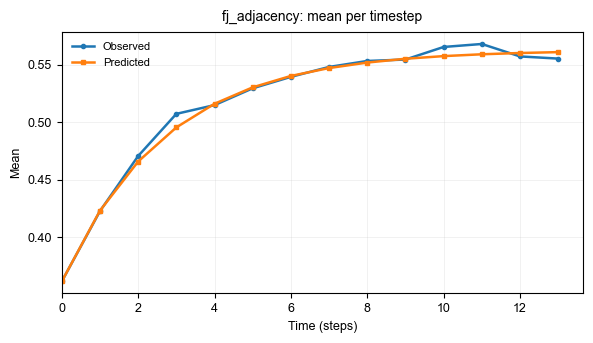

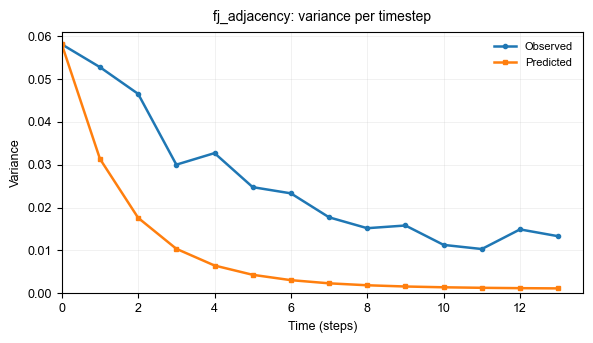

/Users/samuelli/Documents/code/llm/llm-network/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


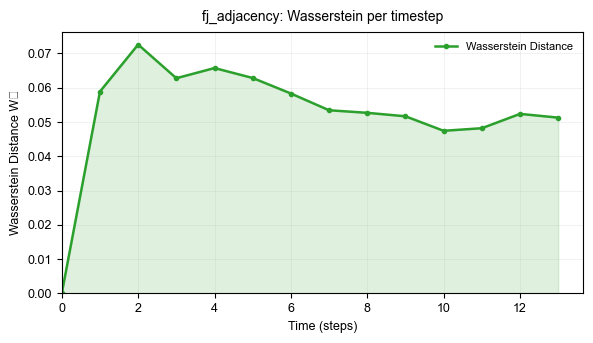

In [5]:
MODEL_RESULTS = {model_name: evaluate_model(model_name, TEST_RUN_TRAJ, rollout_map) for model_name, rollout_map in ROLLOUT_MAPS.items()}
PER_RUN_METRICS = pd.concat([result['per_run'] for result in MODEL_RESULTS.values()], ignore_index=True)
MODEL_SUMMARY = pd.DataFrame([result['summary'] for result in MODEL_RESULTS.values()]).sort_values('run_integral_wasserstein_mean').reset_index(drop=True)
BEST_MODEL = MODEL_SUMMARY.iloc[0]['model']
BEST_MODEL_RESULT = MODEL_RESULTS[BEST_MODEL]
BEST_BY_RUN = PER_RUN_METRICS.sort_values('run_integral_wasserstein').groupby('run_name', as_index=False).first()

print('\nModel ranking by average run-integral Wasserstein:')
print(MODEL_SUMMARY)
print('\nBest model per run:')
print(BEST_BY_RUN[['run_name', 'model', 'run_integral_wasserstein', 'run_max_wasserstein']])

if BEST_MODEL_RESULT['mean_true_stack'].size:
    shared_horizon = min(
        BEST_MODEL_RESULT['mean_true_stack'].shape[1],
        BEST_MODEL_RESULT['mean_pred_stack'].shape[1],
        BEST_MODEL_RESULT['var_true_stack'].shape[1],
        BEST_MODEL_RESULT['var_pred_stack'].shape[1],
        BEST_MODEL_RESULT['wasserstein_stack'].shape[1],
    )
    pu.plot_mean_per_timestep(
        BEST_MODEL_RESULT['mean_true_stack'].mean(axis=0)[:shared_horizon],
        BEST_MODEL_RESULT['mean_pred_stack'].mean(axis=0)[:shared_horizon],
        title=f'{BEST_MODEL}: mean per timestep',
    )
    pu.plot_variance_per_timestep(
        BEST_MODEL_RESULT['var_true_stack'].mean(axis=0)[:shared_horizon],
        BEST_MODEL_RESULT['var_pred_stack'].mean(axis=0)[:shared_horizon],
        title=f'{BEST_MODEL}: variance per timestep',
    )
    pu.plot_wasserstein_distance_per_timestep(
        BEST_MODEL_RESULT['wasserstein_stack'].mean(axis=0)[:shared_horizon],
        title=f'{BEST_MODEL}: Wasserstein per timestep',
    )



Sample run for detailed plots: run_20260506-115251
Sample plot horizon: 15


(<Figure size 1000x350 with 1 Axes>,
 <Axes: title={'center': 'run_20260506-115251: distributions per timestep (fj_adjacency)'}, xlabel='Time (steps)', ylabel='Value'>)

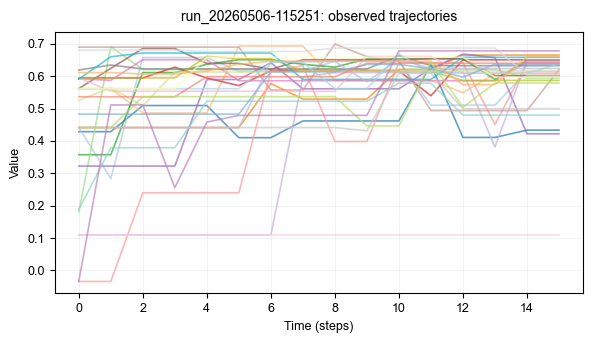

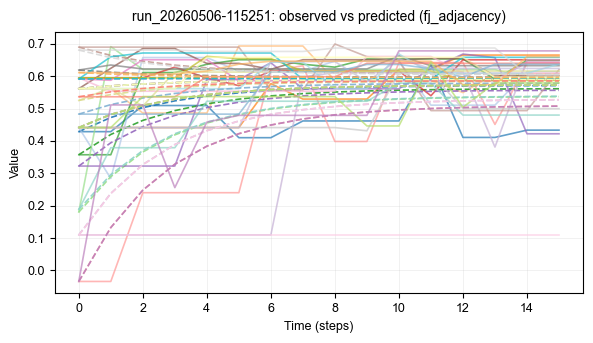

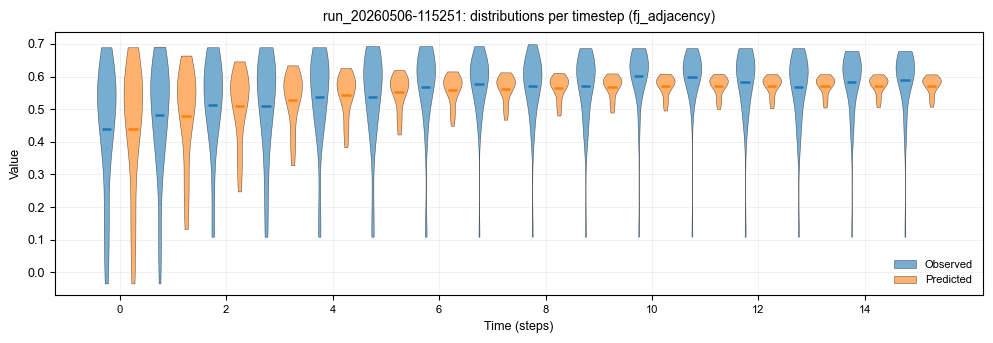

In [6]:
SAMPLE_RUN = max(TEST_RUN_TRAJ, key=lambda run_name: np.asarray(TEST_RUN_TRAJ[run_name], dtype=float).shape[0])
SAMPLE_OBS = np.asarray(TEST_RUN_TRAJ[SAMPLE_RUN], dtype=float)
SAMPLE_PRED = np.asarray(ROLLOUT_MAPS[BEST_MODEL][SAMPLE_RUN], dtype=float)
t_common = min(SAMPLE_OBS.shape[0], SAMPLE_PRED.shape[0])
SAMPLE_OBS = SAMPLE_OBS[:t_common]
SAMPLE_PRED = SAMPLE_PRED[:t_common]
SAMPLE_PLOT_HORIZON = min(
    PARAMS['sample_plot_horizon'],
    SAMPLE_OBS.shape[0] - 1,
    SAMPLE_PRED.shape[0] - 1,
)

print('\nSample run for detailed plots:', SAMPLE_RUN)
print('Sample plot horizon:', SAMPLE_PLOT_HORIZON)
pu.plot_observed_trajectories(
    SAMPLE_OBS,
    title=f'{SAMPLE_RUN}: observed trajectories',
    horizon=SAMPLE_PLOT_HORIZON,
)
pu.plot_predicted_vs_observed(
    SAMPLE_OBS,
    SAMPLE_PRED,
    title=f'{SAMPLE_RUN}: observed vs predicted ({BEST_MODEL})',
    horizon=SAMPLE_PLOT_HORIZON,
)
pu.plot_violin_per_timestep(
    SAMPLE_OBS[: SAMPLE_PLOT_HORIZON + 1],
    SAMPLE_PRED[: SAMPLE_PLOT_HORIZON + 1],
    title=f'{SAMPLE_RUN}: distributions per timestep ({BEST_MODEL})',
)


### Across LLMs and Topics

In [5]:
# Fit homophily+stubbornness on pooled train set for each LLM/topic combination
RUNS_DIR = ROOT / 'runs'
ALL_LLMS = sorted([d.name for d in RUNS_DIR.iterdir() if d.is_dir()])
print(f'Discovered LLMs: {ALL_LLMS}.')

CROSS_LLM_RESULTS = []

for llm_name in ALL_LLMS:
    llm_path = RUNS_DIR / llm_name
    topics = sorted([d.name for d in llm_path.iterdir() if d.is_dir()])
    for topic_name in topics:
        train_path = llm_path / topic_name / 'train'
        if not train_path.exists():
            continue
        run_dirs = sorted([p for p in train_path.iterdir() if p.is_dir()])
        print(f'\n[{llm_name}/{topic_name}] {len(run_dirs)} runs')
        run_data = {r.name: load_run_data(r) for r in run_dirs}
        global_agents = sorted({a for d in run_data.values() for a in d['agent_ids']}, key=_numeric_agent_key)
        n_agents = len(global_agents)
        traj_mask = {rn: build_run_trajectory(d, global_agents, target_agent_fraction=PARAMS['target_agent_fraction'], return_post_mask=True, constrain_messages=PARAMS['constrain_messages']) for rn, d in run_data.items()}
        run_traj = {rn: tm[0] for rn, tm in traj_mask.items()}
        run_neighbors = {rn: build_neighbors_index(d, global_agents) for rn, d in run_data.items()}
        
        # Fit once on pooled train set
        try:
            fit_result = fit_homophily_stubborness(run_traj, run_neighbors, gamma0=1.0)
            CROSS_LLM_RESULTS.append({'llm': llm_name, 'topic': topic_name, 'n_runs': len(run_traj), 'n_agents': n_agents, 'lambda1': fit_result.get('lambda1', np.nan), 'lambda2': fit_result.get('lambda2', np.nan), 'lambda_self': fit_result.get('lambda_self', np.nan), 'alpha': 1 - fit_result.get('lambda_self', np.nan)- fit_result.get('lambda1', np.nan)- fit_result.get('lambda2', np.nan), 'gamma': fit_result.get('gamma', np.nan), 'bias': fit_result.get('bias', np.nan), 'mse_pool': fit_result.get('mse_pool', np.nan), 'success': fit_result.get('success', False)})
            print(f'  Fit successful: λ1={fit_result.get("lambda1", np.nan):.6f}, λ2={fit_result.get("lambda2", np.nan):.6f}, γ={fit_result.get("gamma", np.nan):.6f}, MSE={fit_result.get("mse_pool", np.nan):.6f}')
        except Exception as e:
            print(f'  Fit failed: {str(e)[:60]}')
            CROSS_LLM_RESULTS.append({'llm': llm_name, 'topic': topic_name, 'n_runs': len(run_traj), 'n_agents': n_agents, 'lambda1': np.nan, 'lambda2': np.nan, 'lambda_self': np.nan, 'alpha': np.nan, 'gamma': np.nan, 'bias': np.nan, 'mse_pool': np.nan, 'success': False})

print(f'\nTotal LLM/topic combinations: {len(CROSS_LLM_RESULTS)}')

Discovered LLMs: ['gemma3', 'llama3.1', 'qwen3'].

[gemma3/climate] 24 runs
  Fit successful: λ1=0.006882, λ2=0.339810, γ=0.000000, MSE=0.027022

[gemma3/gun-control] 24 runs
  Fit successful: λ1=0.011511, λ2=0.166400, γ=0.000000, MSE=0.089994

[gemma3/vaccines] 24 runs
  Fit successful: λ1=0.013296, λ2=0.353877, γ=1.666908, MSE=0.011671

[llama3.1/climate] 24 runs
  Fit successful: λ1=0.018573, λ2=0.316995, γ=0.000000, MSE=0.016902

[llama3.1/gun-control] 24 runs
  Fit successful: λ1=0.041207, λ2=0.281127, γ=3.921895, MSE=0.050016

[llama3.1/vaccines] 24 runs
  Fit successful: λ1=0.041680, λ2=0.256469, γ=0.249890, MSE=0.010416

[qwen3/climate] 24 runs
  Fit successful: λ1=0.003237, λ2=0.225776, γ=0.910646, MSE=0.016327

[qwen3/gun-control] 24 runs
  Fit successful: λ1=0.000000, λ2=0.241746, γ=1.091581, MSE=0.044960

[qwen3/vaccines] 24 runs
  Fit successful: λ1=0.000000, λ2=0.230284, γ=4.797691, MSE=0.009165

Total LLM/topic combinations: 9


In [ ]:
# Compile and display results organized by LLM/topic
CROSS_LLM_DF = pd.DataFrame(CROSS_LLM_RESULTS)

# Display organized results with ALL fitted parameters
print("\n" + "="*180)
print("HOMOPHILY + STUBBORNNESS: FITTED PARAMETERS (POOLED TRAIN SET BY LLM/TOPIC)")
print("="*180)

display_cols = ['llm', 'topic', 'n_runs', 'n_agents', 'lambda1', 'lambda2', 'lambda_self', 'bias', 'gamma', 'mse_pool', 'success']
display_df = CROSS_LLM_DF[display_cols].copy()

# Format numeric columns to 6 decimal places for display
for col in ['lambda1', 'lambda2', 'lambda_self', 'bias', 'gamma', 'mse_pool']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.6f}' if pd.notna(x) else 'nan')

print(display_df.to_string(index=False))
print("="*180)

# Export full results to CSV for reference
output_csv = ROOT / 'homophily_stubbornness_pooled_fits.csv'
CROSS_LLM_DF.to_csv(output_csv, index=False)
print(f"\nFull results exported to: {output_csv}\n")


HOMOPHILY + STUBBORNNESS: FITTED PARAMETERS (POOLED TRAIN SET BY LLM/TOPIC)
     llm       topic  n_runs  n_agents  lambda1  lambda2 lambda_self     bias    gamma mse_pool  success
  gemma3     climate      24        30 0.006882 0.339810    0.625333 0.348535 0.000000 0.027022     True
  gemma3 gun-control      24        30 0.011511 0.166400    0.674614 0.217670 0.000000 0.089994     True
  gemma3    vaccines      24        30 0.013296 0.353877    0.598305 0.582548 1.666908 0.011671     True
llama3.1     climate      24        30 0.018573 0.316995    0.657921 0.675667 0.000000 0.016902     True
llama3.1 gun-control      24        30 0.041207 0.281127    0.677666 0.864774 3.921895 0.050016     True
llama3.1    vaccines      24        30 0.041680 0.256469    0.690405 0.596829 0.249890 0.010416     True
   qwen3     climate      24        30 0.003237 0.225776    0.707891 0.532918 0.910646 0.016327     True
   qwen3 gun-control      24        30 0.000000 0.241746    0.665913 0.426479 1.091